In [1]:
import utils_phenom as up
import utils_signal as usig
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
memory_components = {}

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


         	Approximation will be used...
         	Approximation will be used...


In [2]:
import utils_simu as us

from scipy.signal import resample

def nfft(ht: np.ndarray, sampling_frequency: float):
    """
    performs an FFT while keeping track of the frequency bins
    assumes input time series is real (positive frequencies only)

    Parameters
    ----------
    ht: array-like
        Time series to FFT
    sampling_frequency: float
        Sampling frequency of input time series

    Returns
    -------
    hf: array-like
        Single-sided FFT of ft normalised to units of strain / sqrt(Hz)
    f: array-like
        Frequencies associated with hf
    """
    # add one zero padding if time series does not have even number
    # of sampling times
    if np.mod(len(ht), 2) == 1:
        ht = np.append(ht, 0)
    LL = len(ht)
    # frequency range
    ff = sampling_frequency / 2 * np.linspace(0, 1, int(LL / 2 + 1))

    # calculate FFT
    # rfft computes the fft for real inputs
    hf = np.fft.rfft(ht)

    # normalise to units of strain / sqrt(Hz)
    hf = hf / sampling_frequency

    return hf, ff

         	Approximation will be used...


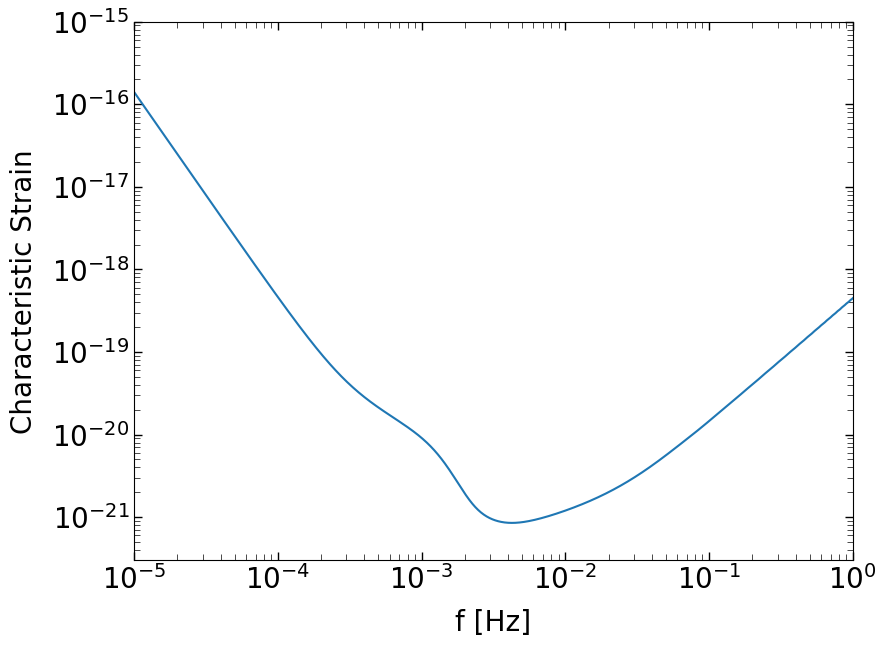

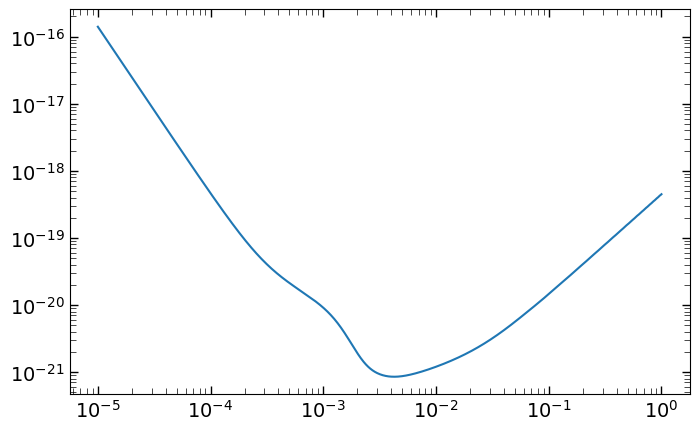

In [3]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

In [4]:
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}



det_styles = {
    'LISA':  {'color': 'black', 'ls': '-',   'lw': 2.0},
    'ET-D':  {'color': 'black', 'ls': '--',  'lw': 1.6},
    'ET-B':  {'color': 'black', 'ls': '-.',  'lw': 1.6},
    'ET-C':  {'color': 'black', 'ls': ':',   'lw': 1.6},
    'aLIGO': {'color': 'grey', 'ls': (0, (3, 1, 1, 1, 1, 1)), 'lw': 1.8},  # dash-dot-dot
}

# 1. 170817

In [5]:
# Parameters 
t = np.linspace(-5., 50., 100000) 
r = 40  * 1e6  
theta = np.deg2rad(32)
# Dynamical ejecta
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_s = 1e-3  

start_dyn, end_dyn = -tau_dyn_s * np.log(3)*1e-3, 10*1e-3  

# Wind ejecta
M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_s = 10  

start_wind, end_wind = 10*1e-3, 10 

# GRB
E_grb = 3e46
theta_j = np.deg2rad(5) # jet opening angle

phi_ej = 0
beta = 0.99
end_grb = 2


# Afterglow 
P_in = 1e50 # check !



Dyn - Wind - GRB - Afterglow

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))


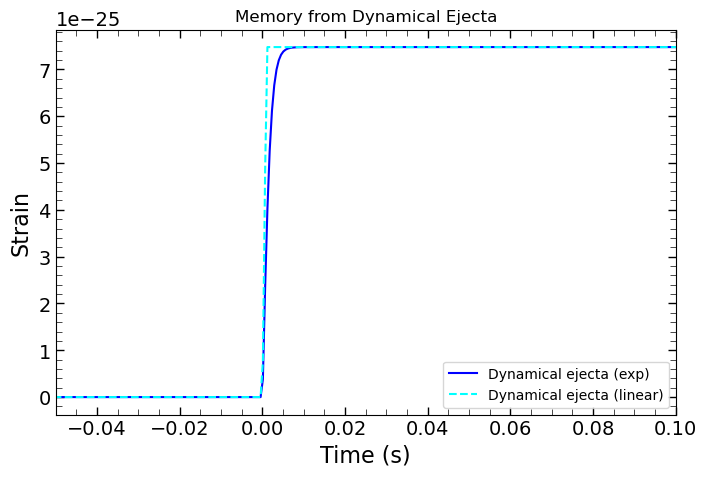

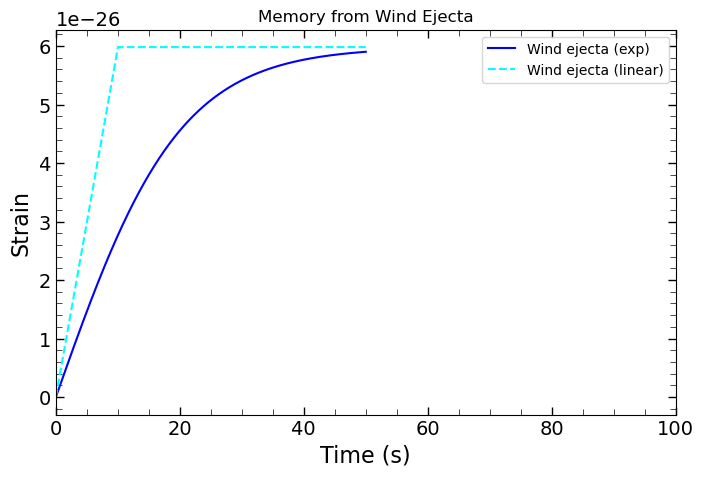

/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))


In [6]:
# Dyn
h_t_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_s, r, start_dyn, model='exponential')
h_t_dyn_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r), tau_dyn_s, start_dyn)

plt.figure(figsize=(8,5))
plt.plot(t, h_t_dyn, label='Dynamical ejecta (exp)', color='blue')
plt.plot(t, h_t_dyn_lin, label='Dynamical ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0.05, 0.1)
plt.title('Memory from Dynamical Ejecta')
plt.legend()
plt.show()

f_dyn, fft_dyn = up.fft_exp_model(h_t_dyn[-1], tau_dyn_s)

f_linear_dyn, fft_dyn_linear = up.memory_fft_formula(up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r), tau_dyn_s, plot=False)

memory_components['dyn'] = {
    't': t,
    'h': h_t_dyn,
    'h_lin': h_t_dyn_lin,
    'f': f_dyn,
    'f_lin': f_linear_dyn,
    'hc': 2* f_dyn * np.abs(fft_dyn),
    'hc_lin':  np.abs(fft_dyn_linear)
}

# Wind
h_t_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_s, r, start_wind, model='exponential')
h_t_wind_lin = up.model_linear(t,up.delta_h_ejecta(M_ej_wind, v_ej_wind, r), tau_wind_s, start_wind)

plt.figure(figsize=(8,5))
plt.plot(t, h_t_wind, label='Wind ejecta (exp)', color='blue')
plt.plot(t, h_t_wind_lin, label='Wind ejecta (linear)', color='cyan', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.xlim(-0, 100)
plt.title('Memory from Wind Ejecta')
plt.legend()
plt.show()


f_wind, fft_wind = up.fft_exp_model(h_t_wind[-1], tau_wind_s)

f_linear_wind, fft_wind_linear = up.memory_fft_formula(up.delta_h_ejecta(M_ej_wind, v_ej_wind, r), tau_wind_s, plot=False)

memory_components['wind'] = {
    't': t,
    'h': h_t_wind,
    'h_lin': h_t_wind_lin,
    'f': f_wind,
    'f_lin': f_linear_wind,
    'hc': 2*f_wind*np.abs(fft_wind),
    'hc_lin': np.abs(fft_wind_linear)
}
# GRB
h_in = up.memory_initial_acceleration_GRB(E_grb, theta, phi_ej, r, beta)
# Afterglow
h_aft = up.memory_afterglow_injection(P_in, end_grb, theta, theta_j, r,  beta)
h_tot, _ = up.memory_total_waveform(t, h_in, h_aft, end_grb, theta)
f, fft_grb_aft = up.new_fft(h_in, h_aft, end_grb, theta)

memory_components['grb'] = {
    't': t,
    'h_in': h_in,
    'h_aft': h_aft,
    'h': h_tot,
    'f': f,
    'hc': 2 * f * np.abs(fft_grb_aft)
}



Nonlinear memory

         	Approximation will be used...
dt_gwmemory: 0.0002, frequency resolution: 5000.0 Hz
 value at t=4.00e-06
h_mem_gwmemory at t=4.0e-06 s: 1.39e-23


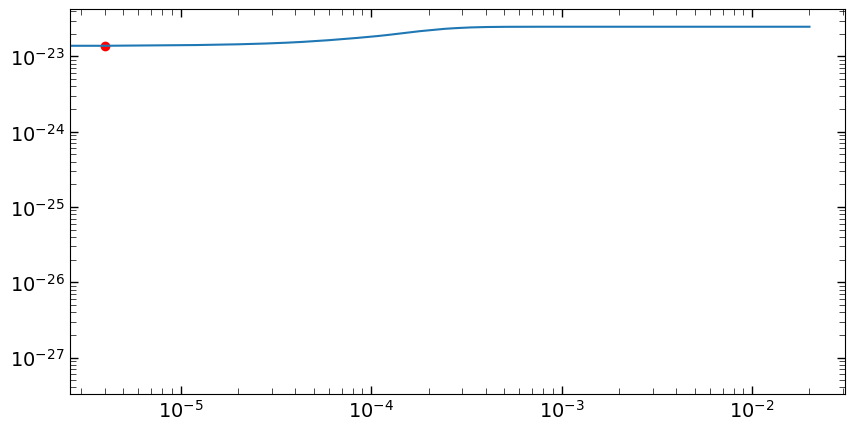

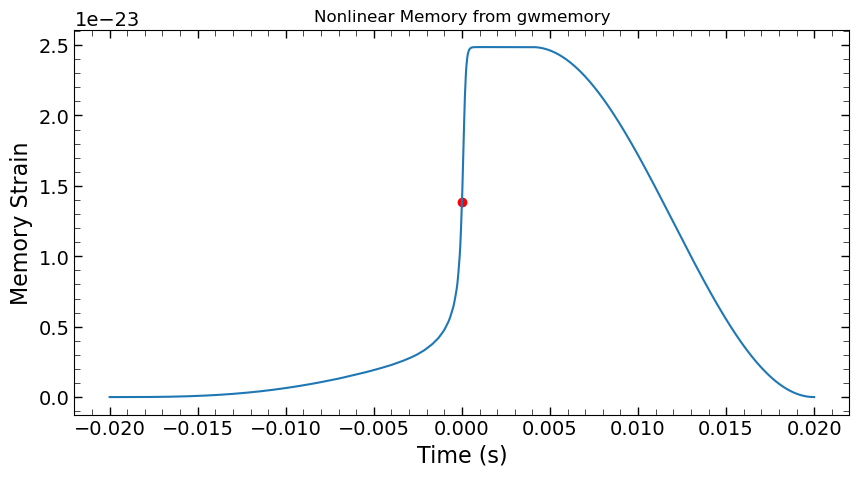

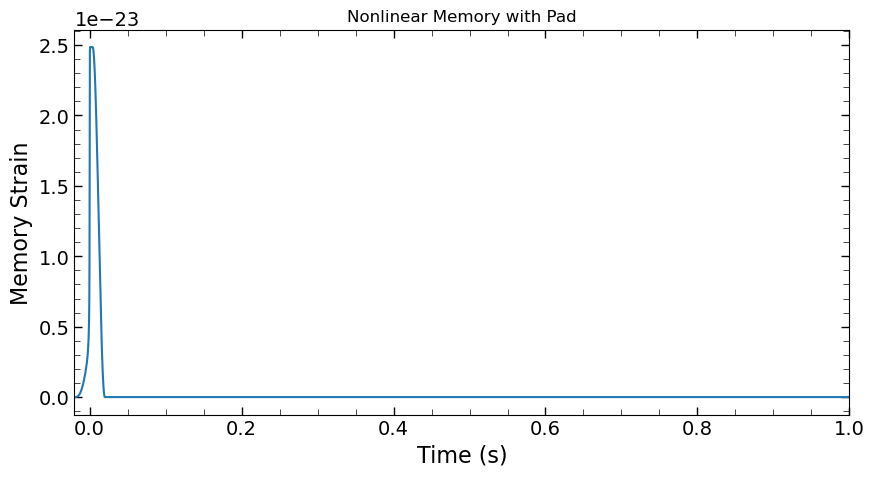

dt = 8.0016e-06 s, f_Nyquist = 6.25e+04 Hz
First 5 frequencies: [0.       0.009998 0.019996 0.029994 0.039992]
0.0 (3.232160915592309e-25+0j)


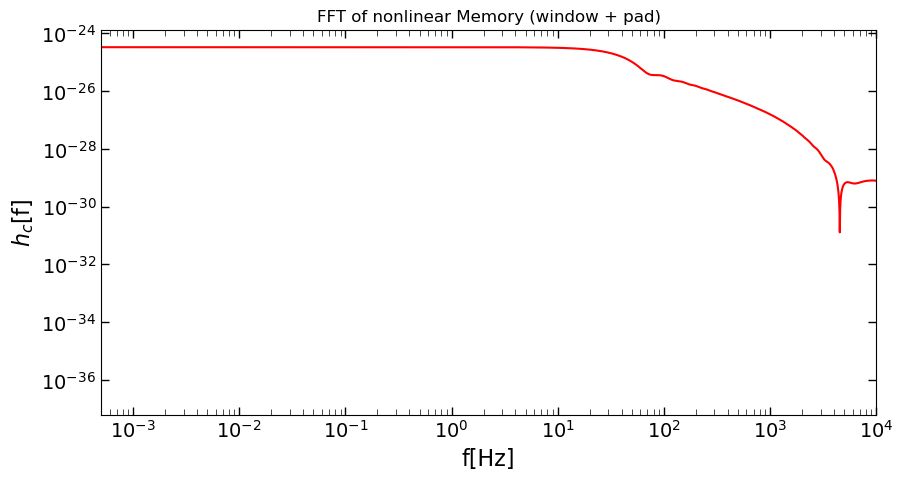

In [7]:
import utils_phenom as up
import utils_signal as using
import importlib
import gwmemory
importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt

dt_gwmemory = 0.0002
df_gwmemory = 1/dt_gwmemory
print(f"dt_gwmemory: {dt_gwmemory}, frequency resolution: {1/dt_gwmemory} Hz")
t_gwmemory = np.linspace(-0.02, 0.02, int(df_gwmemory))
m1 = 1.5
m2 = 1.2
q = m1/m2
parameters = dict(
        total_mass=2.74, distance=40, inc=np.radians(32), q=q, phase=0,
        spin_1=[0.0, 0.0, 0.0], spin_2=[0.0, 0.0, 0.0],
        times=t_gwmemory, model='IMRPhenomD'
        )
h_mem_gwmemory, t_mem_gwmemoy = gwmemory.time_domain_memory(**parameters)
h_mem_gwmemory = h_mem_gwmemory['plus']

plt.figure(figsize=(10, 5))
plt.plot(t_gwmemory, h_mem_gwmemory)

t_target = 4e-6
idx_target = np.argmin(np.abs(t_gwmemory - t_target))
print(f' value at t={t_gwmemory[idx_target]:.2e}')
print(f"h_mem_gwmemory at t={t_target:.1e} s: {h_mem_gwmemory[idx_target]:.2e}")
plt.scatter(t_gwmemory[idx_target], h_mem_gwmemory[idx_target], color='red', label=f'h({t_target:.1e}s)={h_mem_gwmemory[idx_target]:.2e}')
plt.yscale('log')
plt.xscale('log')
plt.show()




h_mem_gwmemory_w = usig.apply_window(h_mem_gwmemory, window_type='tukey', alpha=0.8)

plt.figure(figsize=(10, 5))
plt.plot(t_gwmemory, h_mem_gwmemory_w)
plt.scatter(t_gwmemory[idx_target], h_mem_gwmemory[idx_target], color='red', label=f'h({t_target:.1e}s)={h_mem_gwmemory[idx_target]:.2e}')
plt.xlabel('Time (s)')

plt.ylabel('Memory Strain')
plt.title('Nonlinear Memory from gwmemory')
plt.show()

dt = t_gwmemory[1] - t_gwmemory[0]

# Pad jusqu'à T=100s avec la valeur finale (constante = marche)
t_pad = np.arange(t_gwmemory[-1] + dt, 100.0, dt)
h_pad = np.full_like(t_pad, h_mem_gwmemory_w[-1])

t_full = np.concatenate([t_gwmemory, t_pad])
h_full = np.concatenate([h_mem_gwmemory_w, h_pad])  

plt.figure(figsize=(10, 5))
plt.plot(t_full, h_full)
plt.xlabel('Time (s)')
plt.xlim(-0.02, 1)
plt.ylabel('Memory Strain')
plt.title('Nonlinear Memory with Pad')
plt.show()


hf, ff_nonlinear = nfft(h_full, sampling_frequency=1/dt)
print(f"dt = {dt:.4e} s, f_Nyquist = {0.5/dt:.2e} Hz")
print(f"First 5 frequencies: {ff_nonlinear[:5]}")


#hf = np.fft.rfft(h_mem_gwmemory)
#hf *= dt  # normalisation pour la FFT unitaire
#ff_nonlinear = np.fft.rfftfreq(len(h_mem_gwmemory), d=dt)


print(ff_nonlinear[0], hf[0])
plt.figure(figsize=(10, 5))
plt.plot(ff_nonlinear,  np.abs(hf), c='red')
plt.xscale('log')
plt.yscale('log')
plt.xlim(5e-4, 1e4)
plt.xlabel('f[Hz]')

plt.ylabel(r'$h_c$[f]')
plt.title('FFT of nonlinear Memory (window + pad)')
plt.show()

memory_components['nonlinear'] ={
        't': t_gwmemory,
        'h': h_mem_gwmemory,
        'f': ff_nonlinear[1:],  # skip the zero frequency component
        'hc':  np.abs(hf[1:])  # skip the zero frequency component
}


         	Approximation will be used...
dt_gwmemory: 0.0002, frequency resolution: 5000.0 Hz


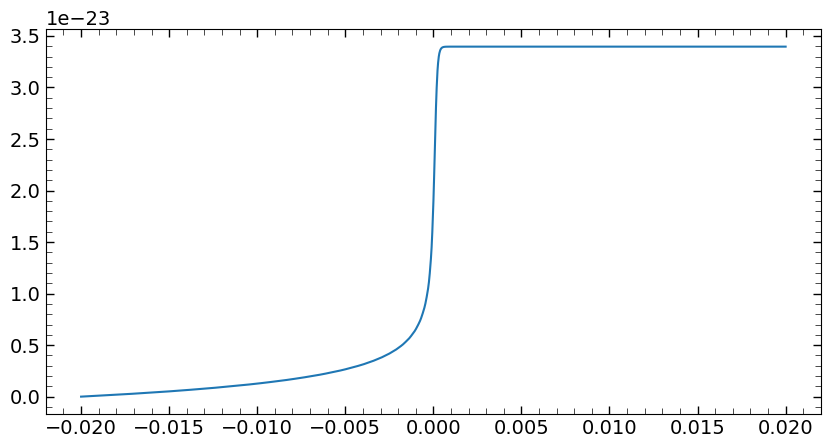

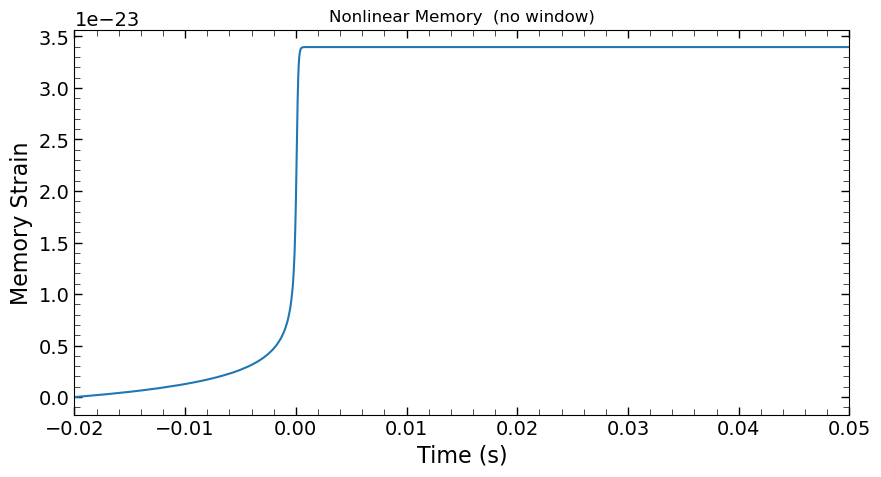

dt = 8.0016e-06 s, f_Nyquist = 6.25e+04 Hz


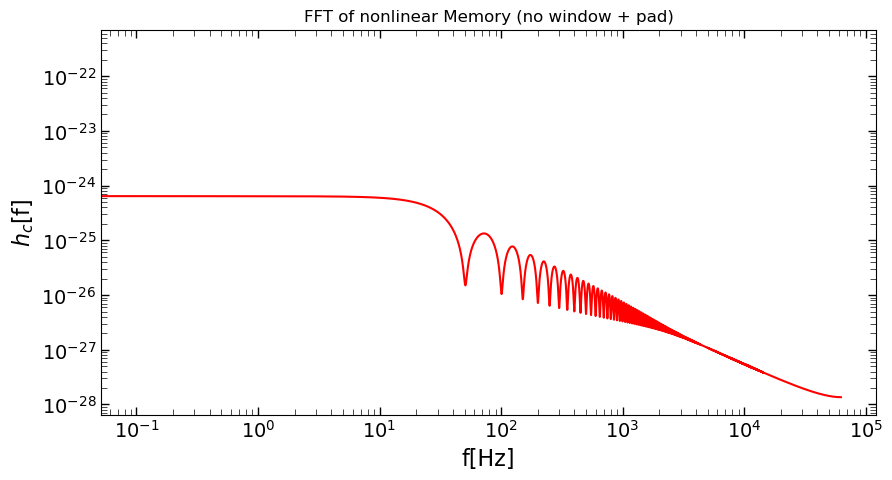

In [8]:
import utils_phenom as up
import utils_signal as using
import importlib
import gwmemory
importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt

dt_gwmemory = 0.0002
df_gwmemory = 1/dt_gwmemory
print(f"dt_gwmemory: {dt_gwmemory}, frequency resolution: {1/dt_gwmemory} Hz")
t_gwmemory = np.linspace(-0.02, 0.02, int(df_gwmemory))
m1 = 1.5
m2 = 1.2
q = m1/m2
parameters = dict(
        total_mass=2.74, distance=100, inc=np.pi/2, q=q, phase=0,
        spin_1=[0.0, 0.0, 0.0], spin_2=[0.0, 0.0, 0.0],
        times=t_gwmemory, model='IMRPhenomD'
        )
h_mem_gwmemory, t_mem_gwmemoy = gwmemory.time_domain_memory(**parameters)
h_mem_gwmemory = h_mem_gwmemory['plus']

plt.figure(figsize=(10, 5))
plt.plot(t_gwmemory, h_mem_gwmemory)
plt.show()


dt = t_gwmemory[1] - t_gwmemory[0]

t_pad = np.arange(t_gwmemory[-1] + dt, 10.0, dt) # Pad jusqu'à T=10s avec la valeur finale 
h_pad = np.full_like(t_pad, h_mem_gwmemory[-1])  # valeur finale SANS Tukey

t_full = np.concatenate([t_gwmemory, t_pad])
h_full = np.concatenate([h_mem_gwmemory, h_pad])  

plt.figure(figsize=(10, 5))
plt.plot(t_full, h_full)
plt.xlabel('Time (s)')
plt.xlim(-0.02, 0.05)
plt.ylabel('Memory Strain')
plt.title('Nonlinear Memory  (no window)')
plt.show()


hf_nowind, ff_nonlinear_nowind = nfft(h_full, sampling_frequency=1/dt)
print(f"dt = {dt:.4e} s, f_Nyquist = {0.5/dt:.2e} Hz")


#hf = np.fft.rfft(h_mem_gwmemory)
#hf *= dt  # normalisation pour la FFT unitaire
#ff_nonlinear = np.fft.rfftfreq(len(h_mem_gwmemory), d=dt)

plt.figure(figsize=(10, 5))
plt.plot(ff_nonlinear_nowind,  np.abs(hf_nowind), c='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('f[Hz]')

plt.ylabel(r'$h_c$[f]')
plt.title('FFT of nonlinear Memory (no window + pad)')
plt.show()



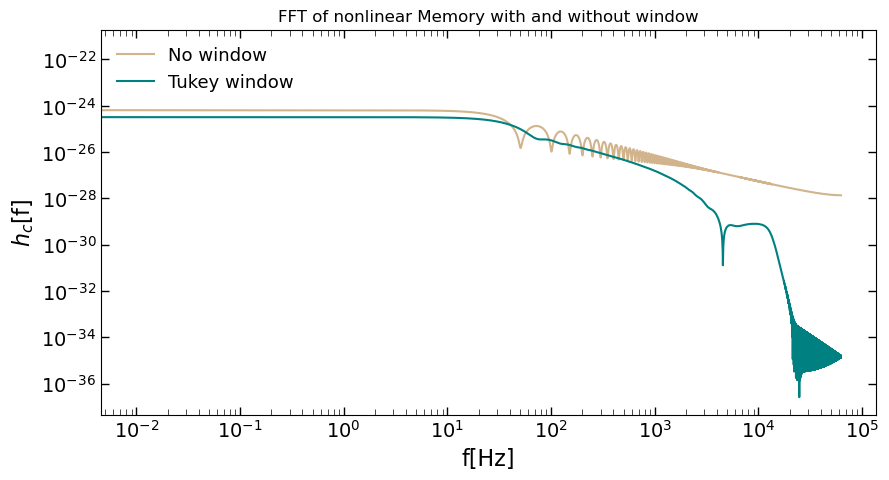

In [9]:
# Plot comparison of FFT with and without window
plt.figure(figsize=(10, 5))
plt.plot(ff_nonlinear_nowind,  np.abs(hf_nowind), c='tan', label='No window')
plt.plot(ff_nonlinear,  np.abs(hf), c='teal', label='Tukey window')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.title('FFT of nonlinear Memory with and without window')
plt.legend(loc = 'upper left', fontsize= 13, frameon=False)
plt.show()

Kilonova

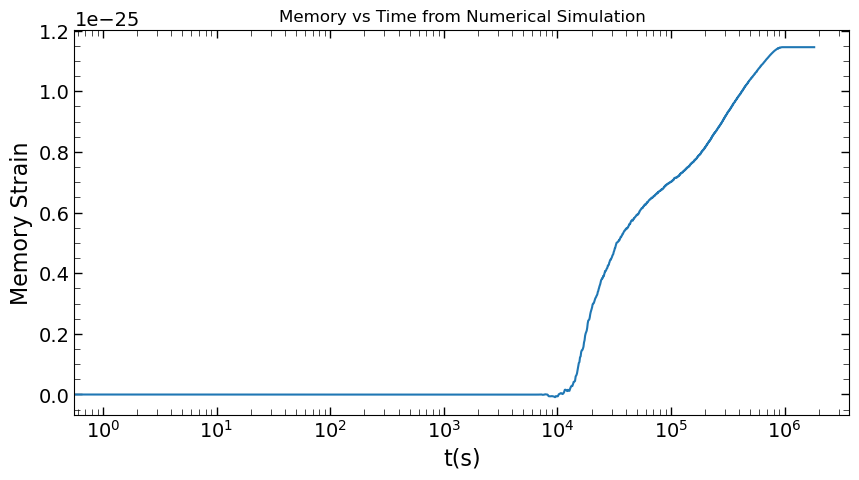

In [10]:
data = np.loadtxt('memory_vs_time_32deg.txt', skiprows=1)
time_data = data[:, 0]
memory_data = data[:, 1]

# Pad the signal from t=0 à t=time_data_seconds[0] par une valeur constante de 0
pad_times = np.linspace(0, time_data[0], len(time_data))  
pad_memory = np.zeros_like(pad_times)

# Concaténer le padding avec les données originales
time_data_seconds_padded = np.concatenate([pad_times, time_data])
memory_data_padded = np.concatenate([pad_memory, memory_data])

# Pad le signal sur 10 s après la fin du signal
pad_times_end = np.linspace(time_data_seconds_padded[-1], time_data_seconds_padded[-1] + 10, len(time_data))  
pad_memory_end = np.full_like(pad_times_end, memory_data_padded[-1])  # Pad avec la dernière valeur du signal
time_data_seconds_padded = np.concatenate([time_data_seconds_padded, pad_times_end])
memory_data_padded = np.concatenate([memory_data_padded, pad_memory_end])

plt.figure(figsize=(10, 5))
plt.plot(time_data_seconds_padded*24*3600, memory_data_padded)
plt.xlabel('t(s)')
plt.xscale('log')
plt.ylabel('Memory Strain')
plt.title('Memory vs Time from Numerical Simulation')
plt.show()


memory_components['kilonova'] = {
        't': time_data_seconds_padded*24*3600,
        'h': memory_data_padded
}


Original time range: 6.61e-02 s to 1.11e+01 s
Original memory range: -1.56e-29 to 1.15e-25


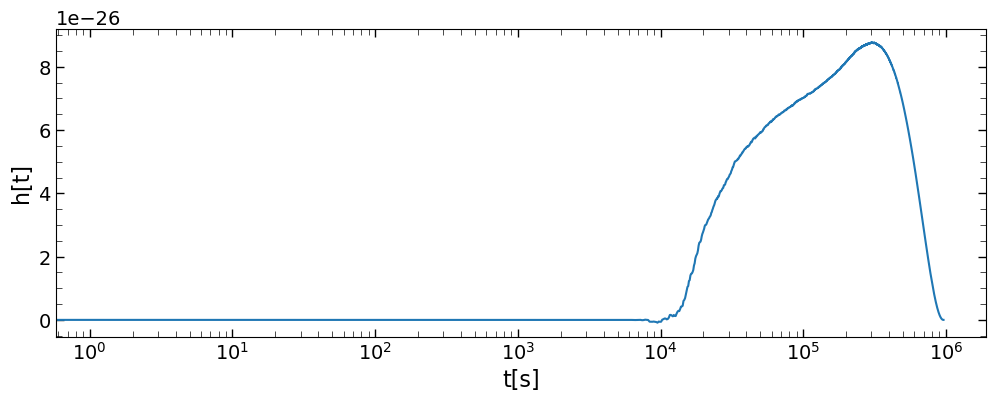

Sampling frequency: 8.75e-01 Hz
Sampling frequency (median): 8.75e-01 Hz
0.4375489172335705 (-1.7322940660650885e-27+0j)


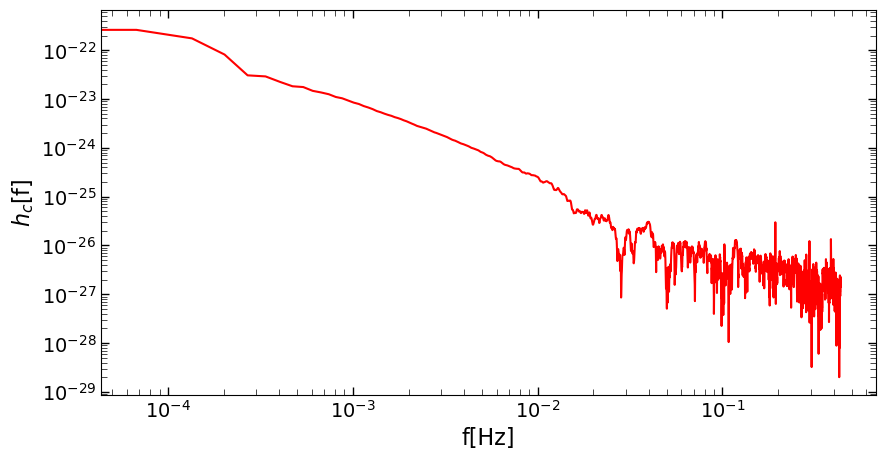

Pente du fit : -0.96 (doit être proche de -1 pour 1/f)


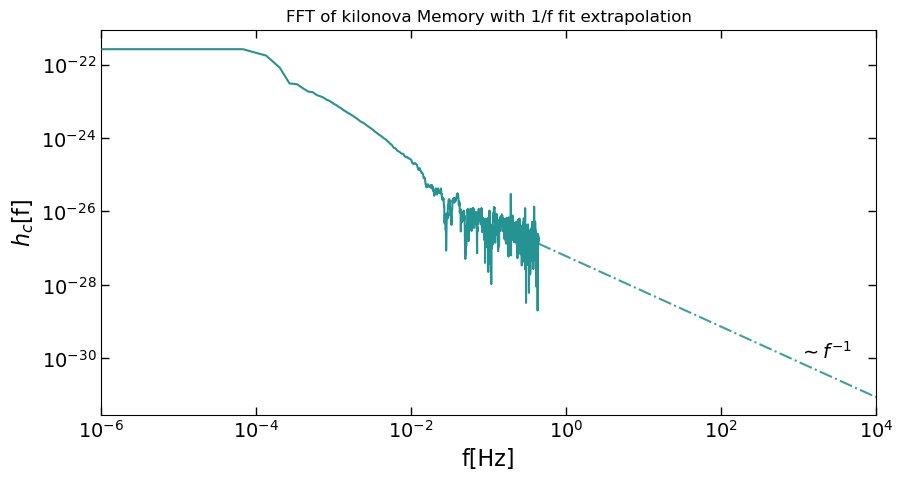

In [35]:
data = np.loadtxt('memory_vs_time_32deg.txt', skiprows=1)
time_data = data[:, 0]
memory_data = data[:, 1]
print(f"Original time range: {time_data[0]:.2e} s to {time_data[-1]:.2e} s")
print(f"Original memory range: {memory_data[0]:.2e} to {memory_data[-1]:.2e}")
# Pad the signal from t=0 à t=time_data_seconds[0] : 0
pad_times = np.linspace(0, time_data[0], len(time_data))  
pad_memory = np.zeros_like(pad_times)

# Concaténer le padding avec les données originales
time_data_seconds_padded = np.concatenate([pad_times, time_data])
memory_data_padded_all = np.concatenate([pad_memory, memory_data])

#memory_data_padded_all = memory_data
#time_data_seconds_padded = time_data


import utils_signal as usig
memory_data_padded = usig.apply_window(memory_data_padded_all, window_type='tukey', alpha=0.8)

time_data_seconds_padded, memory_data_padded = usig.pad_signal(memory_data_padded, time_data_seconds_padded, r=0.3)
# convert days to seconds
time_data_seconds_padded = time_data_seconds_padded * 24 * 3600

plt.figure(figsize=(12,4))
plt.plot(time_data_seconds_padded, memory_data_padded)
plt.xscale('log')
plt.xlabel('t[s]')
plt.ylabel('h[t]')
plt.show()


sampling_frequency=1/(time_data_seconds_padded[1] - time_data_seconds_padded[0])
print(f"Sampling frequency: {sampling_frequency:.2e} Hz")
sampling_frequency_med = 1/np.median(np.diff(time_data_seconds_padded))
print(f"Sampling frequency (median): {sampling_frequency_med:.2e} Hz")

hf_kn, ff_kn = nfft(memory_data_padded, sampling_frequency=sampling_frequency)
print(ff_kn[-1], hf_kn[-1])
plt.figure(figsize=(10, 5))
plt.plot(ff_kn,  np.abs(hf_kn), c='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.show()
#ff_kn, hf_kn =us.memory_fft(time_data_seconds_padded/(24*3600), memory_data_padded, window_type=None, plot_results=True)


mask_fit = (ff_kn > 1e-2) & (ff_kn < 5e-1) 
f_fit = ff_kn[mask_fit]
hc_fit = np.abs(hf_kn)[mask_fit]

# Fit log-log : log(hc) = a*log(f) + b
logf = np.log10(f_fit)
loghc = np.log10(hc_fit)
coeffs = np.polyfit(logf, loghc, 1)
a, b = coeffs
print(f"Pente du fit : {a:.2f} (doit être proche de -1 pour 1/f)")

#Extrapolation du dernier point de la FFT jusqu'à 10 kHz avec la pente du fit
f_extra = np.logspace(np.log10(ff_kn[-1]), np.log10(1e4), 100)
hc_extra = 10**b * f_extra**a  # extrapolation avec la pente du fit


plt.figure(figsize=(10, 5))
plt.plot(f_extra, hc_extra, label='fit 1/f extrapolation', c = 'teal', ls ='-.', alpha=0.75)
plt.plot(ff_kn, np.abs(hf_kn), color='teal', label='Original', zorder=5, alpha=0.85)
plt.text(1e3, 1e-30, r"$\sim f^{-1}$", fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('f[Hz]')
plt.xlim(1e-6, 1e4)
plt.ylabel(r'$h_c$[f]')
plt.title('FFT of kilonova Memory with 1/f fit extrapolation')
plt.show()

# concat 
f_full = np.concatenate([ff_kn, f_extra])
hc_full = np.concatenate([np.abs(hf_kn), hc_extra])

memory_components['kilonova']['f'] = f_full
memory_components['kilonova']['hc'] = hc_full

Plot for the frequency domain

key:  dyn
key:  wind
key:  grb
key:  nonlinear
key:  kilonova


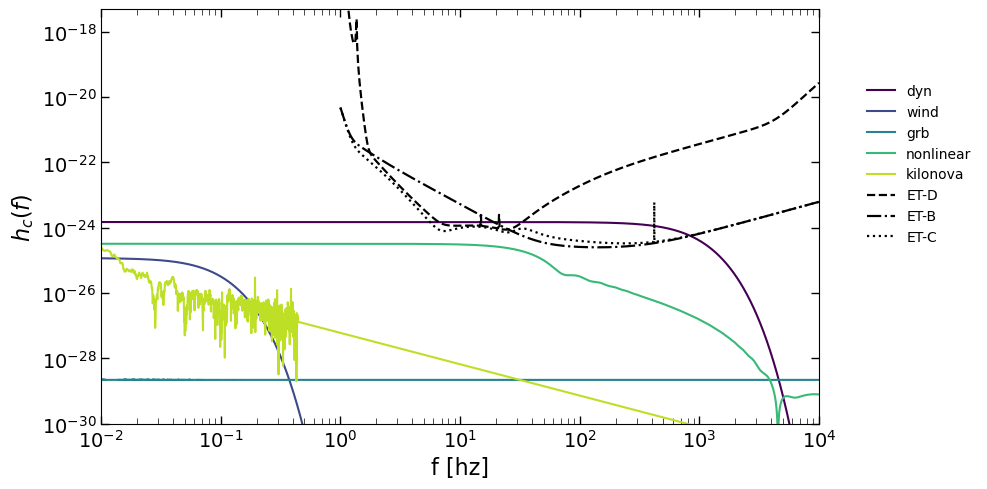

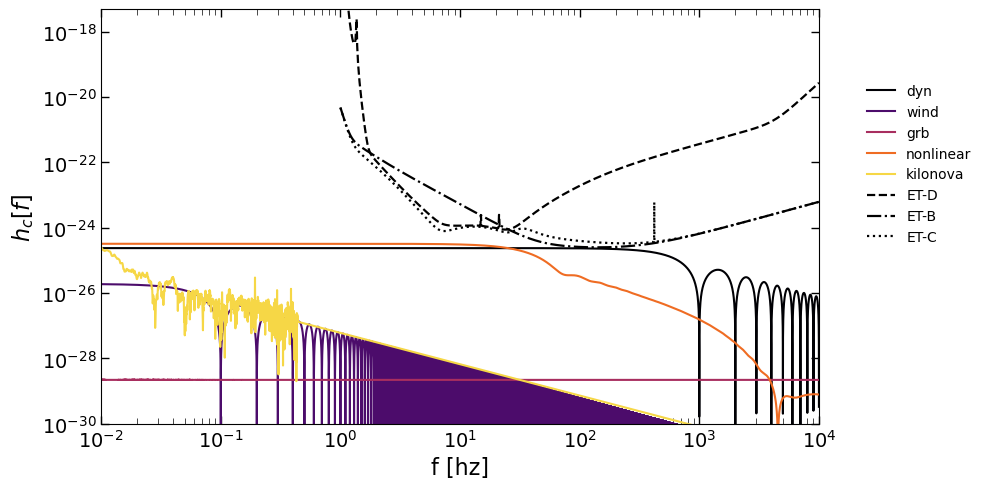

In [12]:
plt.figure(figsize=(10, 5))
cmap = plt.get_cmap('viridis')
# colors based on the number of components of memory_components
colors = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]
labels = list(memory_components.keys())

# plot the freq spectra of the memory components
for key in memory_components:
    print('key: ', key)
    f = memory_components[key]['f']
    hc = memory_components[key]['hc']
    plt.plot(f, hc, label=key, color=colors[labels.index(key)])


det_handles = []
# ET configurations
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = plt.loglog(data[:, 0], data[:, 1],
                         color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                         label=det_label)
    det_handles.append(line)

plt.xscale('log')
plt.xlabel('f [hz]')
plt.ylabel(r'$h_c(f)$')
plt.xlim(1e-2, 1e4)
plt.ylim(1e-30, 5e-18)

plt.legend(loc = 'upper left', frameon=False, bbox_to_anchor=(1.05,0.85))
plt.tight_layout()
plt.show()

# Idem mais on remplace les courbes de mémoire par les courbes linéaires
plt.figure(figsize=(10, 5))
# On fait une list des fft linéaires à partir des composants de mémoire pour le dyn et wind, et on garde les courbes de mémoire pour le grb nonlinear, et la kilonova
fft_list_lin = [memory_components['dyn']['hc_lin'], memory_components['wind']['hc_lin'], memory_components['grb']['hc'], memory_components['nonlinear']['hc'],  memory_components['kilonova']['hc']]
f_list_lin = [memory_components['dyn']['f_lin'], memory_components['wind']['f_lin'], memory_components['grb']['f'],memory_components['nonlinear']['f'], memory_components['kilonova']['f']]
cmap = plt.get_cmap('inferno')
colors_l = [cmap(i) for i in np.linspace(0, 0.9, len(memory_components))]

for f, fft, label, color in zip(f_list_lin, fft_list_lin, labels, colors_l):
    plt.plot(f, fft, label=label, color=color, linestyle='-')
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    line, = plt.loglog(data[:, 0], data[:, 1],
                         color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                         label=det_label)
    det_handles.append(line)
plt.xscale('log')
plt.xlabel('f [hz]')
plt.ylabel(r'$h_c[f]$')
plt.xlim(1e-2, 1e4)
plt.ylim(1e-30, 5e-18)
plt.legend(loc = 'upper left', frameon=False, bbox_to_anchor=(1.05,0.85))
plt.tight_layout()
plt.show()


## Plot of the total memory in the time domain

Linear scale for the time axis

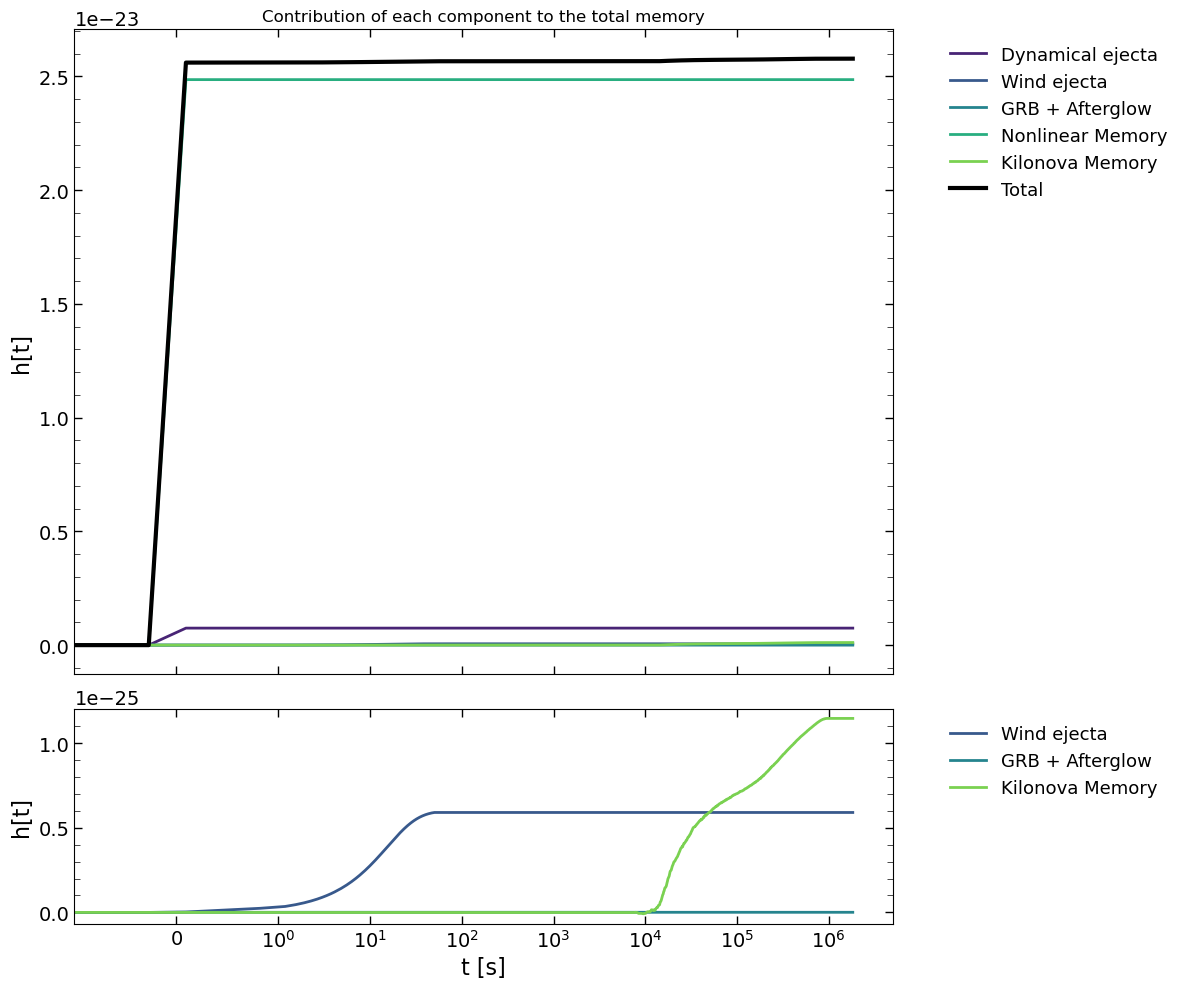

In [13]:
from scipy.interpolate import interp1d

labels = ['Dynamical ejecta ', 'Wind ejecta', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels))]
t_list = [memory_components[key]['t'] for key in memory_components]
h_list = [memory_components[key]['h'] for key in memory_components]

# Grille linéaire en temps, commence à t = -1 s
t_min = -1
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)
t_common = np.linspace(t_min, t_max, N_points)

# Interpolation sur la grille linéaire
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset (échelle log sur l'axe x)
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels, colors):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('symlog', linthresh=1)
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels[i], color=colors[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('symlog', linthresh=1)
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()



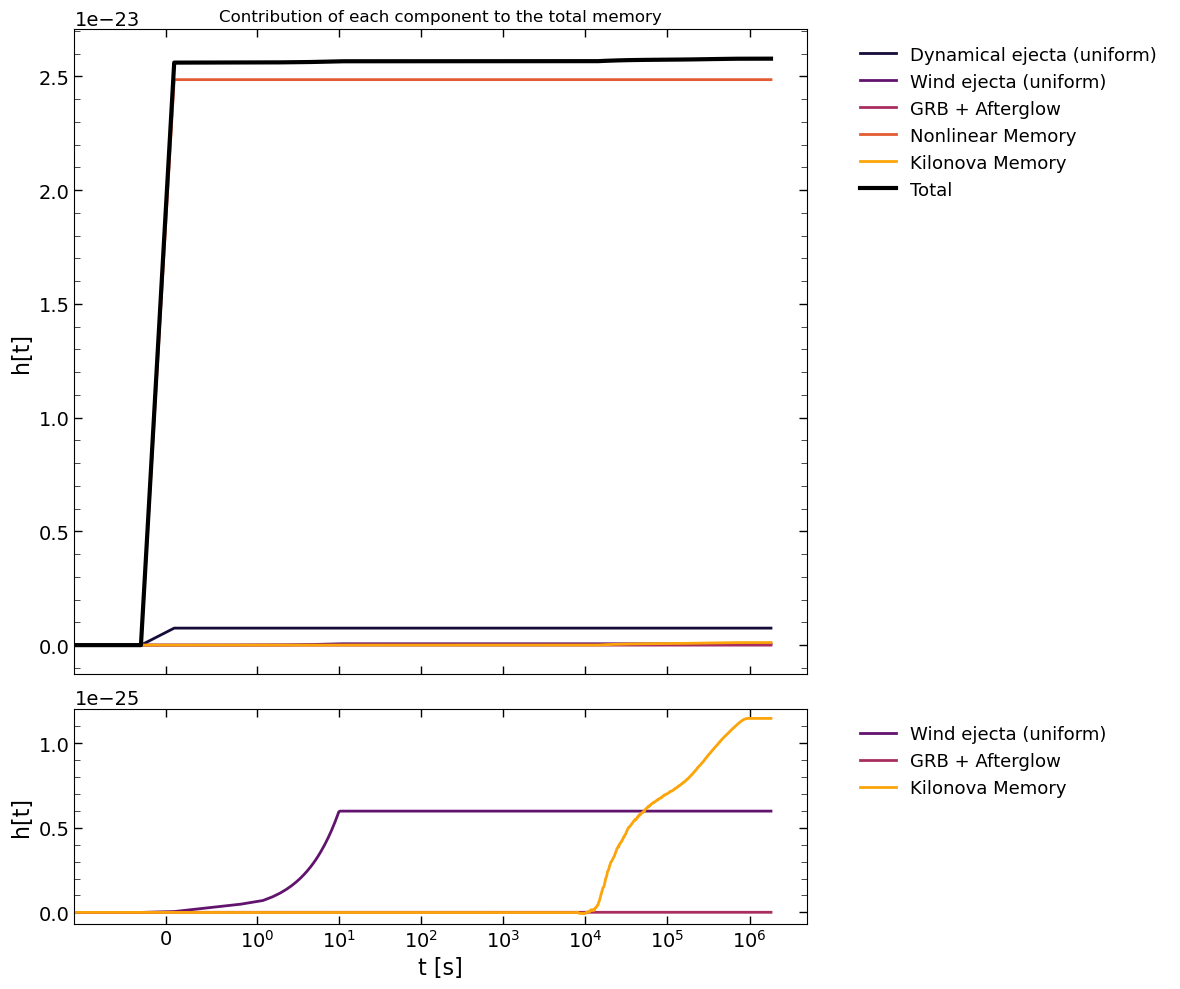

In [14]:
h_lin_dyn = memory_components['dyn']['h_lin']
h_lin_wind = memory_components['wind']['h_lin']
h_list_lin = [h_lin_dyn, h_lin_wind, memory_components['grb']['h'], memory_components['nonlinear']['h'], memory_components['kilonova']['h']]

labels_lin = ['Dynamical ejecta (uniform) ', 'Wind ejecta (uniform)', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('inferno')
colors_lin = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels_lin))]


# Grille linéaire en temps, commence à t = -1 s
t_min = -1
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)
t_common = np.linspace(t_min, t_max, N_points)

# Interpolation sur la grille linéaire
h_interp_list = []

for t, h in zip(t_list, h_list_lin):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common)
    h_interp_list.append(h_interp)


# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset (échelle log sur l'axe x)
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels_lin, colors_lin):
    ax_main.plot(t_common, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('symlog', linthresh=1)
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common, h_interp_list[i], label=labels_lin[i], color=colors_lin[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('symlog', linthresh=1)
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()



Log scale for the time axis

4.000800160032514e-06


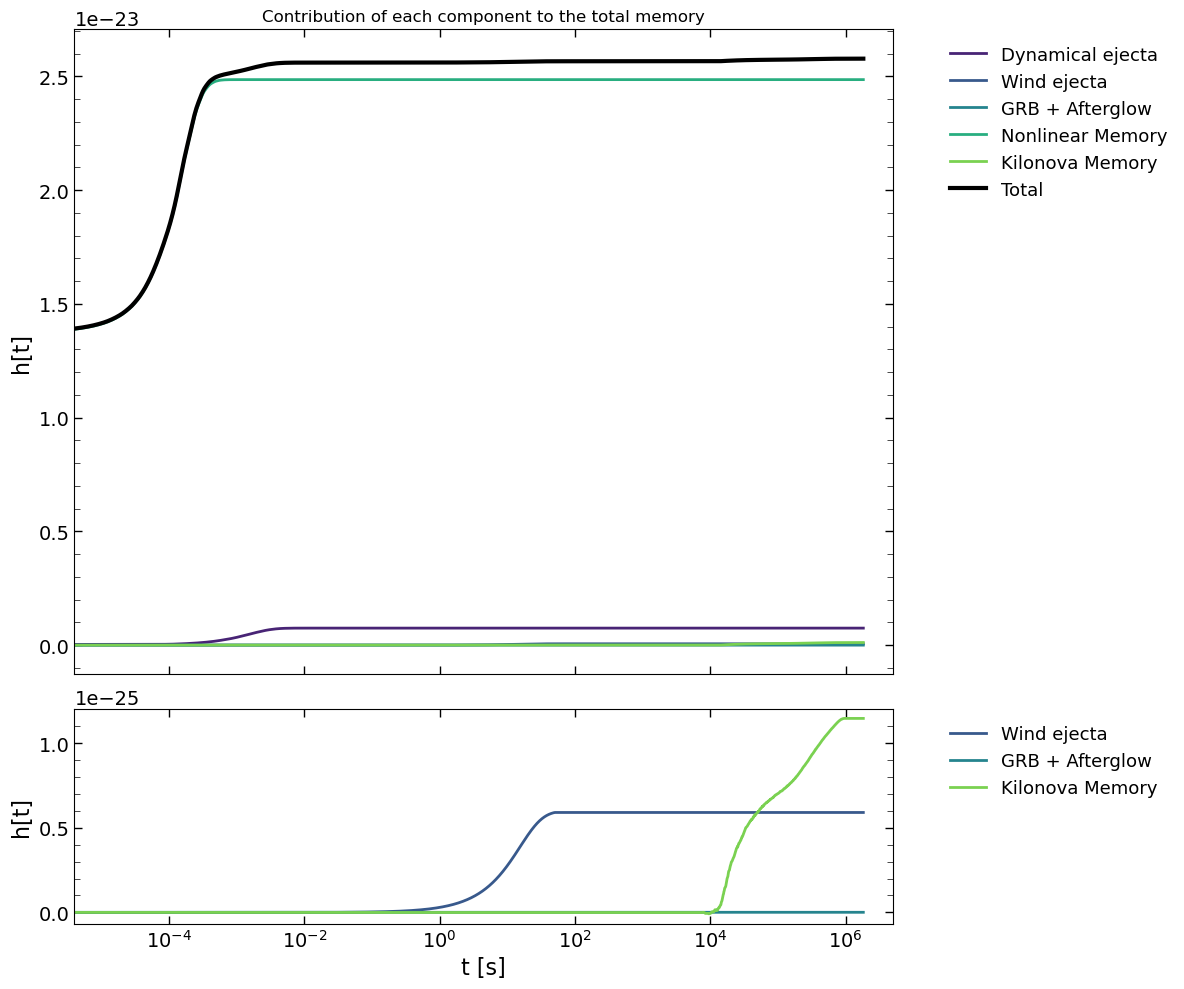

Fréquence de Nyquist estimée : 2.33e+10 Hz


In [15]:
# Log space grid in time for better visualization of the long-term behavior

labels = ['Dynamical ejecta ', 'Wind ejecta', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels))]
t_list = [memory_components[key]['t'] for key in memory_components]
h_list = [memory_components[key]['h'] for key in memory_components]
# Grille logarithmique en temps
t_min_candidates = [t[0] for t in t_list if t[0] > 0]
if len(t_min_candidates) == 0:
    # Si tous les t[0] sont <= 0, prends le plus petit t positif dans tous les tableaux
    t_min = min([np.min(t[t > 0]) for t in t_list if np.any(t > 0)])
    print(t_min)
else:
    t_min = min(t_min_candidates)
t_max = max([t[-1] for t in t_list])
N_points = int(5e6)  

t_common_log = np.logspace(np.log10(t_min), np.log10(t_max), N_points)

# Interpolation sur la grille log
h_interp_list = []
for t, h in zip(t_list, h_list):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common_log)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels, colors):
    ax_main.plot(t_common_log, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_log, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')
ax_main.set_xlim(t_min, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common_log, h_interp_list[i], label=labels[i], color=colors[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(t_min, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Vérification de la fréquence de Nyquist
dt_min = np.min(np.diff(t_common_log))
print(f"Fréquence de Nyquist estimée : {0.5/dt_min:.2e} Hz")


/tmp/ipykernel_430364/3027581151.py:39: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(-1, 5e6)
/tmp/ipykernel_430364/3027581151.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_inset.set_xlim(-1, 5e6)


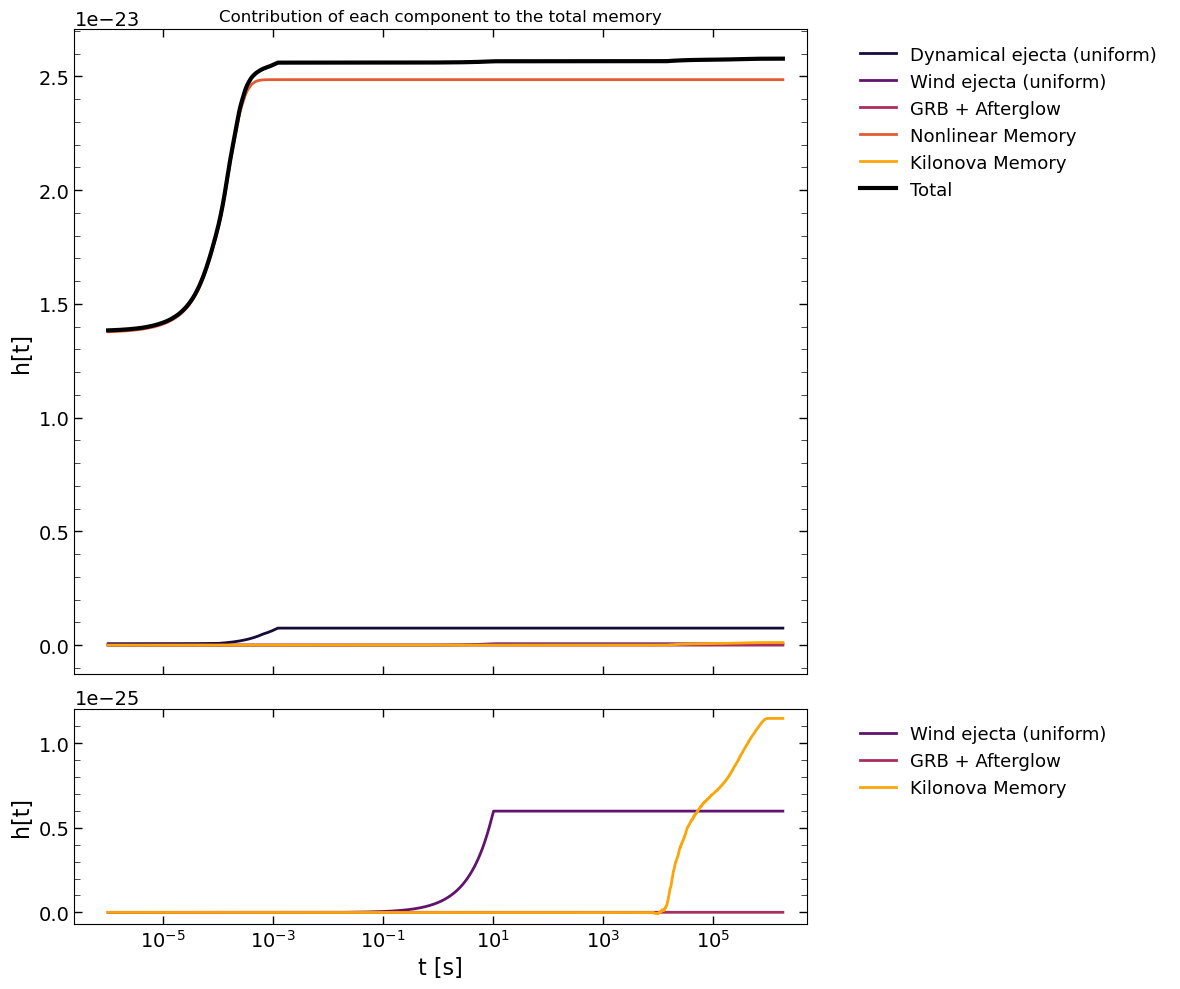

Fréquence de Nyquist estimée : 8.85e+08 Hz


In [16]:
# Same for linear models of dyn and wind

h_lin_dyn = memory_components['dyn']['h_lin']
h_lin_wind = memory_components['wind']['h_lin']
h_list_lin = [h_lin_dyn, h_lin_wind, memory_components['grb']['h'], memory_components['nonlinear']['h'], memory_components['kilonova']['h']]

labels_lin = ['Dynamical ejecta (uniform) ', 'Wind ejecta (uniform)', 'GRB + Afterglow', 'Nonlinear Memory', 'Kilonova Memory']
cmap = plt.get_cmap('inferno')
colors_lin = [cmap(i) for i in np.linspace(0.1, 0.8, len(labels_lin))]

# Définir t_min pour la grille log (doit être > 0)
t_min_log = 1e-6  # ou la plus petite valeur positive de t_list
t_max = max([t[-1] for t in t_list])
N_points = int(5e4)

t_common_log = np.logspace(np.log10(t_min_log), np.log10(t_max), N_points)

# Interpolation sur la grille log
h_interp_list = []
for t, h in zip(t_list, h_list_lin):
    interp_func = interp1d(t, h, kind='linear', bounds_error=False, fill_value=(h[0], h[-1]))
    h_interp = interp_func(t_common_log)
    h_interp_list.append(h_interp)

# Somme simple
h_total = np.sum(h_interp_list, axis=0)

# Plot principal + inset
fig, (ax_main, ax_inset) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for h_interp, label, color in zip(h_interp_list, labels_lin, colors_lin):
    ax_main.plot(t_common_log, h_interp, label=label, color=color, lw=2)
ax_main.plot(t_common_log, h_total, label='Total', color='k', lw=3)
ax_main.set_ylabel('h[t]')
ax_main.set_title('Contribution of each component to the total memory')
ax_main.set_xscale('log')

# Afficher à partir de t = -1 s
ax_main.set_xlim(-1, 5e6)
ax_main.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

idx = [1, 2, 4]
for i in idx:
    ax_inset.plot(t_common_log, h_interp_list[i], label=labels_lin[i], color=colors_lin[i], lw=2)
ax_inset.set_xlabel('t [s]')
ax_inset.set_ylabel('h[t]')
ax_inset.set_xscale('log')
ax_inset.set_xlim(-1, 5e6)
ax_inset.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

dt_min = np.min(np.diff(t_common_log))
print(f"Fréquence de Nyquist estimée : {0.5/dt_min:.2e} Hz")

## Plot of the total memory in the frequency domain

TF of the total memory

Sampling frequency: 2.74e-02 Hz, max frequency: 1.37e-02 Hz given by Nyquist


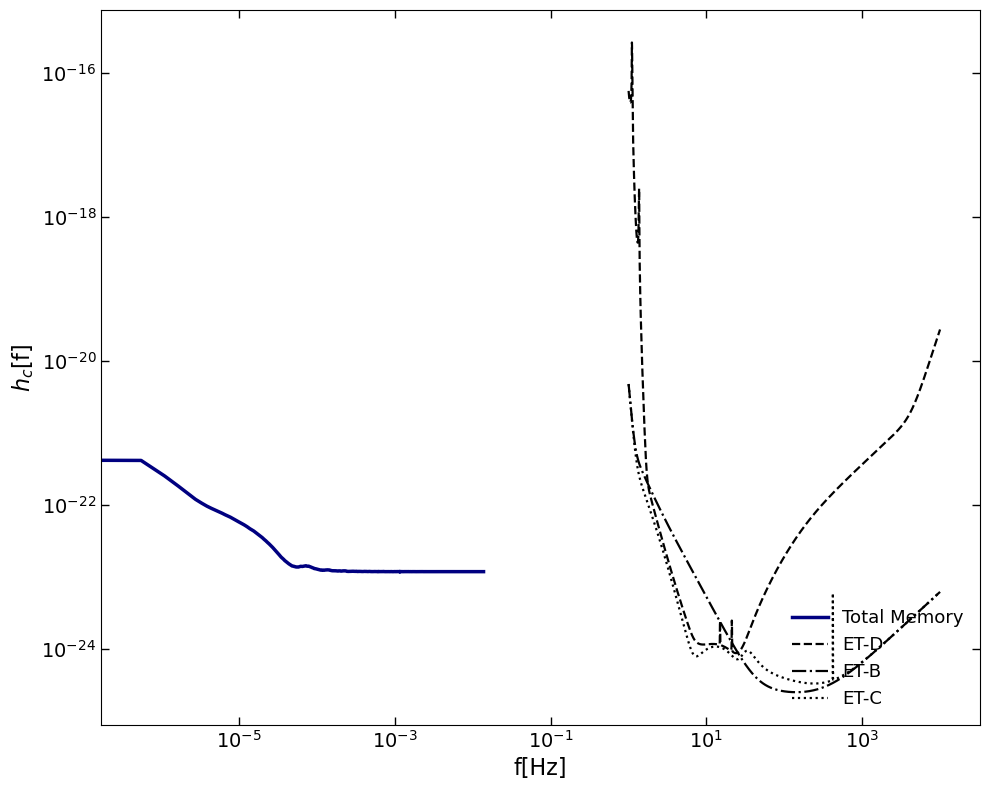

In [17]:
# TF de la somme totale + comparaison avec courbes sensi ET
# use nfft method

t_uniform = np.linspace(t_common_log[0], t_common_log[-1], N_points)
h_uniform = np.interp(t_uniform, t_common_log, h_total)
dt = t_uniform[1] - t_uniform[0]
fft_total = np.fft.rfft(h_uniform)
f_total = np.fft.rfftfreq(len(h_uniform), d=dt)

print(f"Sampling frequency: {1/dt:.2e} Hz, max frequency: {0.5/dt:.2e} Hz given by Nyquist")

plt.figure(figsize=(10, 8))
plt.plot(f_total,  np.abs(fft_total), label='Total Memory', color='navy', lw=2.5)

for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
                 color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
                 label=det_label)
plt.xscale('log')
plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')


plt.legend(loc = 'lower right', frameon=False, fontsize= 13)
plt.tight_layout()
plt.show()

Sum of each TF

Dynamical ejecta (uniform)  False False
Wind ejecta (uniform) False False
GRB + Afterglow False False
Nonlinear Memory False False
Kilonova Memory False False
hc_total:  False
100000.0 2.2021139927464037e-29


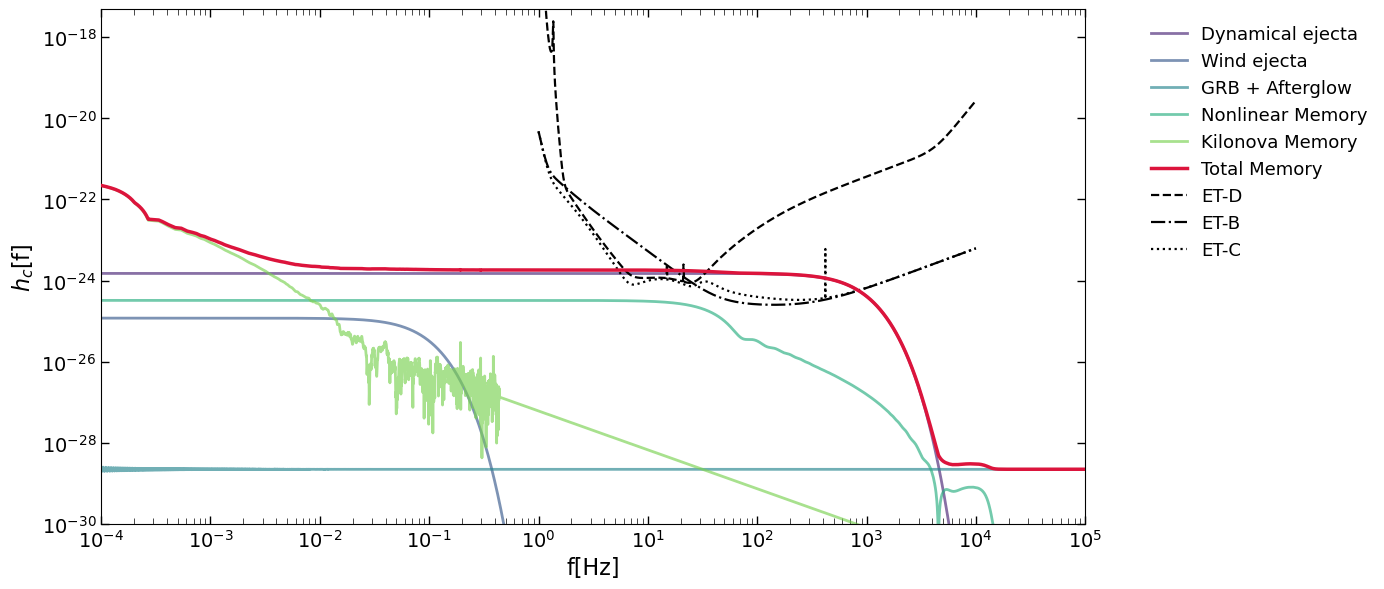

In [ ]:
from scipy.interpolate import interp1d

# Grille fréquentielle commune
f_common = np.logspace(-4, 5, 50000)

hc_total = np.zeros_like(f_common)

f_list = [memory_components[key]['f'] for key in memory_components]
fft_list = [memory_components[key]['hc'] for key in memory_components]
f_list_lin = [memory_components[key]['f_lin'] if 'f_lin' in memory_components[key] else memory_components[key]['f'] for key in memory_components]
fft_list_lin = [memory_components[key]['hc_lin'] if 'hc_lin' in memory_components[key] else memory_components[key]['hc'] for key in memory_components]
plt.figure(figsize=(14, 6))
for i, (f_i, hc_i) in enumerate(zip(f_list, fft_list)):
    interp_func = interp1d(f_i, hc_i, kind='linear', bounds_error=False, fill_value=(hc_i[0], hc_i[-1]))
    hc_interp = interp_func(f_common)
    plt.loglog(f_common, hc_interp, label=labels[i], color=colors[i], lw=2, alpha = 0.65)
    hc_interp = np.nan_to_num(hc_interp, nan=0.0, posinf=0.0, neginf=0.0)
    hc_total += hc_interp

for i, (f_i, hc_i) in enumerate(zip(f_list_lin, fft_list_lin)):
    print(labels_lin[i], np.any(np.isnan(f_i)), np.any(np.isnan(hc_i)))
print('hc_total: ', np.any(np.isnan(hc_total)))
# Plot

plt.loglog(f_common, hc_total, label='Total Memory', color='crimson', lw=2.5, zorder=100)
print(f_common[-1], hc_total[-1])
for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
               color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
               label=det_label)

plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.xlim(1e-4, 1e5)
plt.ylim(1e-30, 5e-18)
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

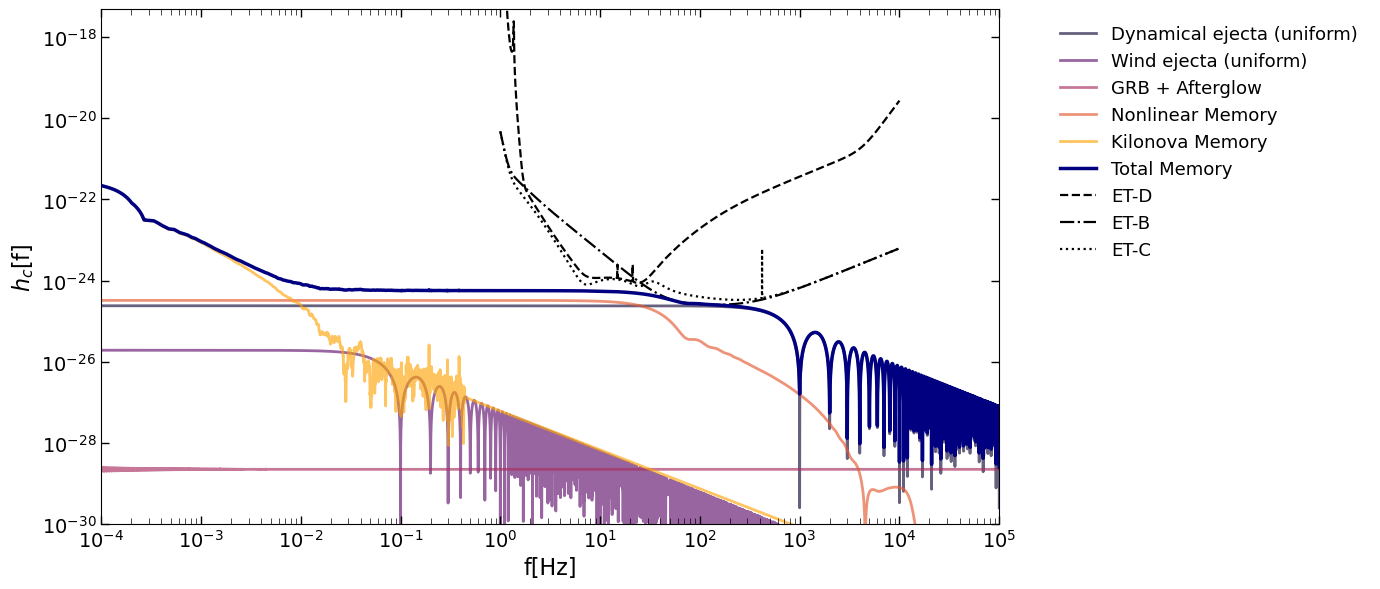

In [19]:
from scipy.interpolate import interp1d

# Grille fréquentielle commune
f_common_lin = np.logspace(-4, 5, 10000)

# fft_list_lin = [fft_dyn_linear, fft_wind_linear, fft_list[2], fft_list[3], fft_list[4]]
# f_list_lin   = [f_linear_dyn,   f_linear_wind,   f_list[2],   f_list[3],   f_list[4]]


hc_total_lin = np.zeros_like(f_common_lin)

f_list = [memory_components[key]['f'] for key in memory_components]
fft_list = [memory_components[key]['hc'] for key in memory_components]
f_list_lin = [memory_components[key]['f_lin'] if 'f_lin' in memory_components[key] else memory_components[key]['f'] for key in memory_components]
fft_list_lin = [memory_components[key]['hc_lin'] if 'hc_lin' in memory_components[key] else memory_components[key]['hc'] for key in memory_components]
plt.figure(figsize=(14, 6))
for i, (f_i, hc_i) in enumerate(zip(f_list_lin, fft_list_lin)):
    interp_func = interp1d(f_i, hc_i, kind='linear', bounds_error=False, fill_value=(hc_i[0], hc_i[-1]))
    hc_interp = interp_func(f_common_lin)
    plt.loglog(f_common_lin, hc_interp, label=labels_lin[i], color=colors_lin[i], lw=2, alpha=0.65, zorder=-10)
    hc_total_lin += hc_interp

# Plot

plt.loglog(f_common_lin, hc_total_lin, label='Total Memory', color='navy', lw=2.5, zorder=100)

for det_label, data in et_sensitivities.items():
    s = det_styles[det_label]
    plt.loglog(data[:, 0], data[:, 1],
               color=s['color'], linestyle=s['ls'], linewidth=s['lw'],
               label=det_label)

plt.xlabel('f[Hz]')
plt.ylabel(r'$h_c$[f]')
plt.xlim(1e-4, 1e5)
plt.ylim(1e-30, 5e-18)
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## SNR 

In [20]:
# test de différent hc_total pour le calcul de snr
def compute_total_hc(
    f_common,
    params_dyn,
    params_wind,
    params_grb,
    memory_components
):
    """
    Calcule la somme des hc interpolés sur f_common pour chaque composant de mémoire.
    Les composants nonlinéaire et kilonova sont récupérés directement du dict memory_components.
    Les autres sont recalculés à partir des paramètres fournis.

    params_dyn: dict, paramètres pour dyn (ex: {'M_ej':..., 'v_ej':..., 'tau':..., 'r':..., 'start':..., 'model':...})
    params_wind: dict, idem pour wind
    params_grb: dict, paramètres pour grb+afterglow (ex: {'E_grb':..., 'theta':..., 'phi_ej':..., 'r':..., 'beta':..., 'end_grb':..., 'P_in':..., 'theta_j':...})
    memory_components: dict, contient déjà 'nonlinear' et 'kilonova' avec leurs 'f' et 'hc'
    f_common: array, grille fréquentielle commune

    Retourne: hc_total (array, même taille que f_common)
    """

    hc_total = np.zeros_like(f_common)
    # Dynamical ejecta
    t_dyn = np.linspace(-5., 50., 100000)
    h_dyn = up.linear_memory_ejecta_masked(
        t_dyn,
        params_dyn['M_ej'],
        params_dyn['v_ej'],
        params_dyn['tau'],
        params_dyn['r'],
        params_dyn['start'],
        model=params_dyn.get('model', 'exponential')
    )
    f_dyn, fft_dyn = up.fft_exp_model(h_dyn[-1], params_dyn['tau'])
    hc_dyn = 2 * f_dyn * np.abs(fft_dyn)
    interp_dyn = interp1d(f_dyn, hc_dyn, kind='linear', bounds_error=False, fill_value=(hc_dyn[0], hc_dyn[-1]))
    interp_dyn = np.nan_to_num(interp_dyn, nan=0.0, posinf=0.0, neginf=0.0)

    hc_total += interp_dyn(f_common)

    t_wind = np.linspace(-5., 50., 100000)
    h_wind = up.linear_memory_ejecta_masked(
        t_wind,
        params_wind['M_ej'],
        params_wind['v_ej'],
        params_wind['tau'],
        params_wind['r'],
        params_wind['start'],
        model=params_wind.get('model', 'exponential')
    )
    f_wind, fft_wind = up.fft_exp_model(h_wind[-1], params_wind['tau'])
    hc_wind = 2 * f_wind * np.abs(fft_wind)
    hc_wind = np.nan_to_num(hc_wind, nan=0.0, posinf=0.0, neginf=0.0)  

    interp_wind = interp1d(f_wind, hc_wind, kind='linear', bounds_error=False, fill_value=(hc_wind[0], hc_wind[-1]))
    hc_interp_wind = interp_wind(f_common)
    hc_interp_wind = np.nan_to_num(hc_interp_wind, nan=0.0, posinf=0.0, neginf=0.0)  


    hc_total += hc_interp_wind

    # GRB + Afterglow
    h_in = up.memory_initial_acceleration_GRB(
        params_grb['E_grb'],
        params_grb['theta'],
        params_grb['phi_ej'],
        params_grb['r'],
        params_grb['beta']
    )
    h_aft = up.memory_afterglow_injection(
        params_grb['P_in'],
        params_grb['end_grb'],
        params_grb['theta'],
        params_grb['theta_j'],
        params_grb['r'],
        params_grb['beta']
    )
    t_grb = np.linspace(-5., 50., 100000)
    h_tot, _ = up.memory_total_waveform(t_grb, h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    f_grb, fft_grb_aft = up.new_fft(h_in, h_aft, params_grb['end_grb'], params_grb['theta'])
    hc_grb = 2 * f_grb * np.abs(fft_grb_aft)
    interp_grb = interp1d(f_grb, hc_grb, kind='linear', bounds_error=False, fill_value=(hc_grb[0], hc_grb[-1]))
    interp_grb = np.nan_to_num(interp_grb, nan=0.0, posinf=0.0, neginf=0.0)

    hc_total += interp_grb(f_common)

    # Nonlinear memory (déjà calculé)
    f_nl = memory_components['nonlinear']['f']
    hc_nl = memory_components['nonlinear']['hc']
    interp_nl = interp1d(f_nl, hc_nl, kind='linear', bounds_error=False, fill_value=(hc_nl[0], hc_nl[-1]))
  
    hc_total += interp_nl(f_common)

    # Kilonova (déjà calculé)
    f_kn = memory_components['kilonova']['f']
    hc_kn = memory_components['kilonova']['hc']
    interp_kn = interp1d(f_kn, hc_kn, kind='linear', bounds_error=False, fill_value=(hc_kn[0], hc_kn[-1]))

    hc_total += interp_kn(f_common)


    return hc_total

In [21]:
params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
params_grb = {'E_grb': 3e47, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
f = np.logspace(-4, 5, 50000)
hc_total_1 = compute_total_hc(f, params_dyn, params_wind, params_grb, memory_components)


/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return (2*delta_h * (1/(1 + np.exp(-t / tau))-0.5))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: overflow encountered in sinh
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in multiply
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))
/home/stu_brabant/Memory_effect/All_memory/utils_phenom.py:188: RuntimeWarning: invalid value encountered in divide
  h_f =  delta_h *np.pi * tau /( 1j*np.sinh( np.pi * f * tau))


In [22]:
def compute_snr(f_signal, h_c, f_noise, h_n):
    f_signal = np.array(f_signal)
    h_c = np.array(h_c)
    f_noise = np.array(f_noise)
    h_n = np.array(h_n)

    interp_hn = interp1d(f_noise, h_n, kind='linear', bounds_error=False, fill_value='extrapolate')
    h_n_interp = interp_hn(f_signal)

    integrand = (h_c**2) / (h_n_interp**2)
    snr_squared = np.trapezoid(integrand, x=np.log(f_signal))
    snr = np.sqrt(snr_squared)
    return snr

In [23]:
et_d_data = et_sensitivities['ET-D']
f_noise = et_d_data[:, 0]
h_n = et_d_data[:, 1]
snr_1 = compute_snr(f, hc_total_1, f_noise, h_n)

print(f"SNR for total memory with ET-D: {snr_1:.2f}")


SNR for total memory with ET-D: 2.15


In [24]:
# ET-D configuration
et_d_data = et_sensitivities['ET-D']
f_noise = et_d_data[:, 0]
h_n = et_d_data[:, 1]
snr_1 = compute_snr(f_common, hc_total, f_noise, h_n)
snr_2 = compute_snr(f_common_lin, hc_total_lin, f_noise, h_n)
print(f"SNR for total memory with ET-D: {snr_1:.2f}")
print(f"SNR for total memory (uniform models) with ET-D: {snr_2:.2f}")

SNR for total memory with ET-D: 2.15
SNR for total memory (uniform models) with ET-D: 0.62


Map de SNR

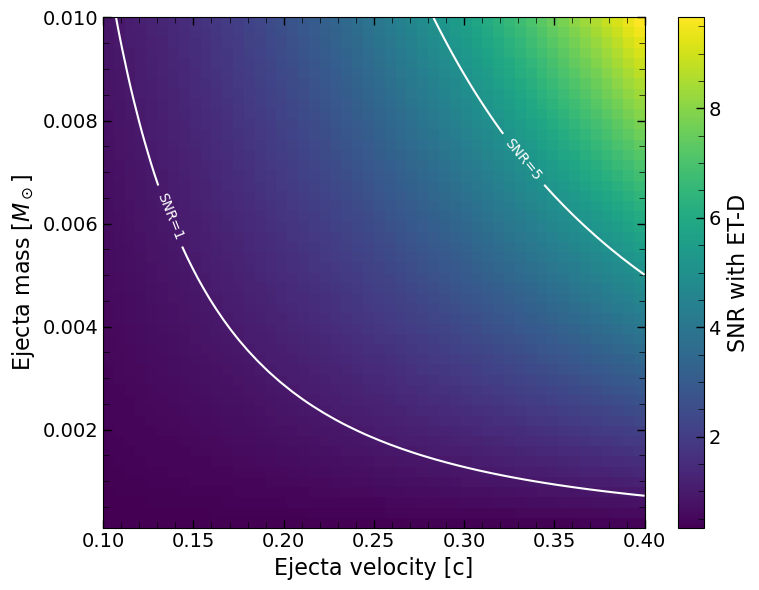

In [25]:
# Test 1 : different mass /velocity of ejecta for the dynamical component
M_ej_values = np.linspace(1e-4, 1e-2, 50)  # in solar masses
v_ej_values = np.linspace(0.1, 0.4, 50)  # in c
snr_results = np.zeros((len(M_ej_values), len(v_ej_values)))
for i, M_ej in enumerate(M_ej_values):
    for j, v_ej in enumerate(v_ej_values):
        params_dyn = {'M_ej': M_ej, 'v_ej': v_ej, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': 3e47, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)
# Plot heatmap of SNR as a function of M_ej and v_ej
plt.figure(figsize=(8, 6))
plt.imshow(snr_results, extent=(v_ej_values[0], v_ej_values[-1], M_ej_values[0], M_ej_values[-1]), aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar(label='SNR with ET-D')
plt.xlabel('Ejecta velocity [c]')
plt.ylabel(r'Ejecta mass [$M_\odot$]')


# Ajout des isobars 
levels = [1, 5, 10,  50]
contours = plt.contour(v_ej_values, M_ej_values, snr_results, levels=levels, colors='white')
plt.clabel(contours, inline=True, fontsize=10, fmt='SNR=%d')
plt.tight_layout()

plt.show()

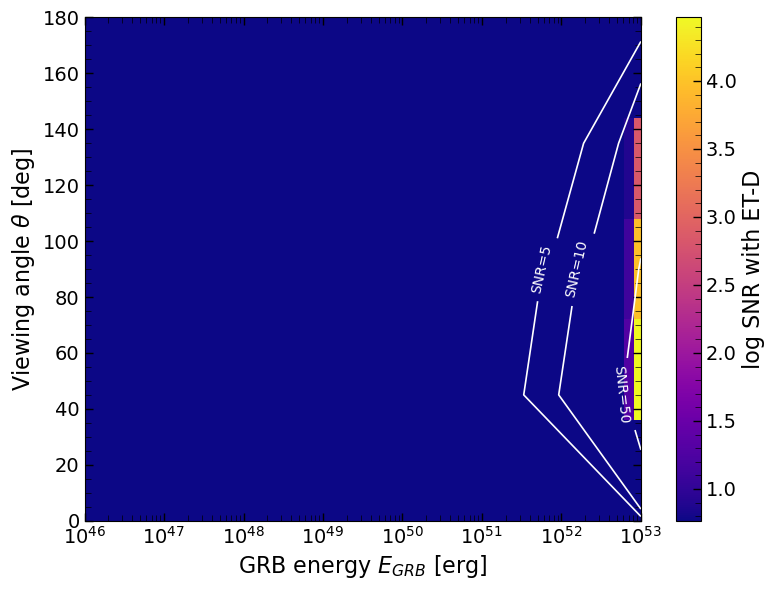

In [26]:
# Paramètres pour le test
theta_values = np.linspace(0, np.pi, 5)  # in radians
E_grb_values = np.logspace(46, 53, 5)

theta_grid, E_grid = np.meshgrid(theta_values, E_grb_values, indexing='ij')
snr_results_grb = np.zeros_like(theta_grid)

for i in range(theta_grid.shape[0]):
    for j in range(theta_grid.shape[1]):
        theta = theta_grid[i, j]
        E_grb = E_grid[i, j]
        params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': 0.01, 'v_ej': 0.05, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': E_grb, 'theta': theta, 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results_grb[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)

theta_deg_values = np.degrees(theta_values)
theta_deg_grid = np.degrees(theta_grid)

plt.figure(figsize=(8, 6))
im = plt.imshow(
    np.log(snr_results_grb),
    extent=(E_grb_values[0], E_grb_values[-1], theta_deg_values[0], theta_deg_values[-1]),
    aspect='auto',
    origin='lower',
    cmap='plasma',
    interpolation='nearest'
)

plt.colorbar(label='log SNR with ET-D')
plt.xlabel(r'GRB energy $E_{GRB}$ [erg]')
plt.ylabel(r'Viewing angle $\theta$ [deg]')

plt.xscale('log')

# Ajout des isobars 
levels = [1, 5, 10,  50]
contours = plt.contour(
    E_grid, theta_deg_grid, snr_results_grb, levels=levels, colors='white', linewidths=1.2
)
plt.clabel(contours, inline=True, fontsize=10, fmt='SNR=%d')
plt.tight_layout()

plt.show()

SNR min: 2.1786696728200603 SNR max: 2.178669672820075


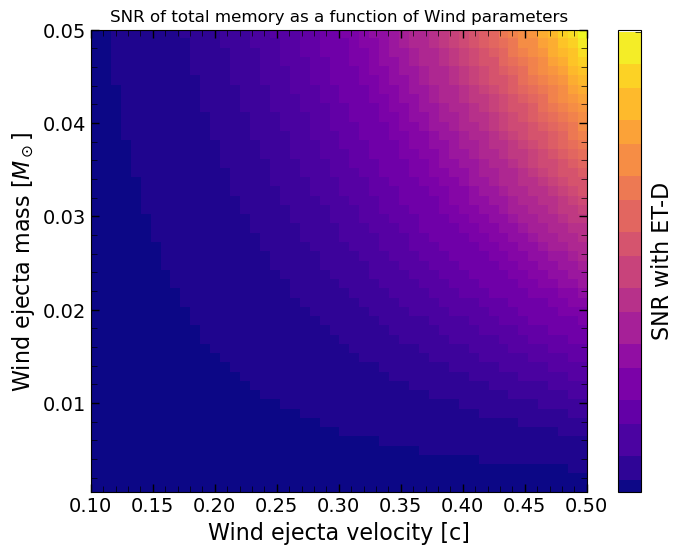

In [27]:
# Paramètres pour le test
M_ej_wind_values = np.linspace(5e-4, 5e-2, 50)  # in solar masses
v_ej_wind_values = np.linspace(0.1, 0.5, 50)  # in c
Me_j_grid, v_ej_grid = np.meshgrid(M_ej_wind_values, v_ej_wind_values, indexing='ij')
snr_results_wind = np.zeros_like(Me_j_grid)
for i in range(Me_j_grid.shape[0]):
    for j in range(Me_j_grid.shape[1]):
        M_ej_wind = Me_j_grid[i, j]
        v_ej_wind = v_ej_grid[i, j]
        # ! change E_grb to e49 
        params_dyn = {'M_ej': 0.5e-2, 'v_ej': 0.25, 'tau': 1e-3, 'r': 40e6, 'start': -1e-3, 'model': 'exponential'}
        params_wind = {'M_ej': M_ej_wind, 'v_ej': v_ej_wind, 'tau': 10, 'r': 40e6, 'start': 0.01, 'model': 'exponential'}
        params_grb = {'E_grb': 3e49, 'theta': np.deg2rad(32), 'phi_ej': 0, 'r': 40e6, 'beta': 0.99, 'end_grb': 2, 'P_in': 1e50, 'theta_j': np.deg2rad(5)}
        hc_total_test = compute_total_hc(f_common, params_dyn, params_wind, params_grb, memory_components)
        snr_results_wind[i, j] = compute_snr(f_common, hc_total_test, f_noise, h_n)


print('SNR min:', np.min(snr_results_wind), 'SNR max:', np.max(snr_results_wind))

plt.figure(figsize=(8, 6))
im = plt.imshow(
    snr_results_wind,
    extent=(v_ej_wind_values[0], v_ej_wind_values[-1], M_ej_wind_values[0], M_ej_wind_values[-1]),
    aspect='auto',
    origin='lower',
    cmap='plasma', 
    interpolation='nearest'
)
plt.colorbar(label='SNR with ET-D')
plt.xlabel(r'Wind ejecta velocity [c]')
plt.ylabel(r'Wind ejecta mass [$M_\odot$]')
plt.title('SNR of total memory as a function of Wind parameters')

# Choisis des niveaux adaptés à ta plage de SNR
levels = [1, 5]
contours = plt.contour(
    v_ej_grid, Me_j_grid, snr_results_wind, levels=levels, colors='white', linewidths=1.2
)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

plt.show()

Petit impact sur le SNR 

## GRBS

1. BOAT + afterglow
2. ULGRBs (day-long or ~4.2h ? ~7h with 4 episodes equaly spaced ?) of GRB 250702BD : https://arxiv.org/pdf/2507.14286 - https://arxiv.org/pdf/2509.26283 
3. Closest GRB : GRB 980425/SN 1998bw. Located at a distance of 36.9 Mpc 
    - E_tot ?= 1e48 erg (obtained via a special model : https://www.sciencedirect.com/science/article/pii/S0273117704006295)
    - E_iso ?= 6e47 erg (https://scispace.com/pdf/an-off-axis-jet-model-for-grb-980425-and-low-energy-gamma-7cxl121i2s.pdf) with a jet half opening angle $\Delta\theta$:  10°<= $\Delta \theta$ <=30°